<a href="https://colab.research.google.com/github/sschares/ores5160-2026/blob/main/Schares_ORES5160-2026_Final_Project_redo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Load combined dataset from BigQuery
from google.colab import auth
auth.authenticate_user()

!pip install google-cloud-bigquery

from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="project-6a80f461-7192-4ba7-a5f")

# SQL queries must be passed as strings to the BigQuery client.
query = """
SELECT *
FROM `project-6a80f461-7192-4ba7-a5f.synthea_patients.combined_patient_encounters`
"""

# Execute the query and load the results into a Pandas DataFrame
df = client.query(query).to_dataframe()

In [ ]:
#Display dataset sample
df.head()

,ZIP,HEALTHCARE_EXPENSES,DEATHDATE,MAIDEN,MARITAL,STATE,BIRTHDATE,ETHNICITY,ORGANIZATION,DESCRIPTION,...,PREFIX,RACE,ADDRESS,PROVIDER,START,PATIENT,Id,PATIENT_ID,LAT,PASSPORT
0,2128,1272094.625,None,None,M,Massachusetts,1958-05-07,nonhispanic,00717240-296a-35b2-a336-8e3d9f085fce,General examination of patient (procedure),...,Mr.,white,801 Block Lane Apt 35,35b68d18-e67e-37f7-aa49-fcc046f1a289,2012-05-30 18:15:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,7da3a8f6-ae2f-47a1-9cbd-09e792bb5c3f,bfb101aa-8d36-422b-8e5c-b7275d279de0,42.318568,X58347333X
1,2128,1272094.625,None,None,M,Massachusetts,1958-05-07,nonhispanic,00717240-296a-35b2-a336-8e3d9f085fce,General examination of patient (procedure),...,Mr.,white,801 Block Lane Apt 35,35b68d18-e67e-37f7-aa49-fcc046f1a289,2014-06-11 18:15:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,c031a292-af66-4724-a3bd-13feba60a265,bfb101aa-8d36-422b-8e5c-b7275d279de0,42.318568,X58347333X
2,2128,1272094.625,None,None,M,Massachusetts,1958-05-07,nonhispanic,00717240-296a-35b2-a336-8e3d9f085fce,General examination of patient (procedure),...,Mr.,white,801 Block Lane Apt 35,35b68d18-e67e-37f7-aa49-fcc046f1a289,2010-05-19 18:15:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,c9b65029-984d-4c8e-b6e5-f24b4c3320fb,bfb101aa-8d36-422b-8e5c-b7275d279de0,42.318568,X58347333X
3,2128,1272094.625,None,None,M,Massachusetts,1958-05-07,nonhispanic,00717240-296a-35b2-a336-8e3d9f085fce,General examination of patient (procedure),...,Mr.,white,801 Block Lane Apt 35,35b68d18-e67e-37f7-aa49-fcc046f1a289,2011-05-25 18:15:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,d8212a9d-fb80-4a39-bbb5-850738aa993d,bfb101aa-8d36-422b-8e5c-b7275d279de0,42.318568,X58347333X
4,2128,1272094.625,None,None,M,Massachusetts,1958-05-07,nonhispanic,00717240-296a-35b2-a336-8e3d9f085fce,General examination of patient (procedure),...,Mr.,white,801 Block Lane Apt 35,35b68d18-e67e-37f7-aa49-fcc046f1a289,2015-06-17 18:15:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,aa00fafc-442c-4061-a5e5-a1d38da642d6,bfb101aa-8d36-422b-8e5c-b7275d279de0,42.318568,X58347333X


In [ ]:
#Display complete list of column names for reordering
print("Current columns in DataFrame df:")
print(df.columns.tolist())

Current columns in DataFrame df:
['ZIP', 'HEALTHCARE_EXPENSES', 'DEATHDATE', 'MAIDEN', 'MARITAL', 'STATE', 'BIRTHDATE', 'ETHNICITY', 'ORGANIZATION', 'DESCRIPTION', 'ENCOUNTERCLASS', 'GENDER', 'TOTAL_CLAIM_COST', 'COUNTY', 'SUFFIX', 'STOP', 'BASE_ENCOUNTER_COST', 'PAYER_COVERAGE', 'REASONDESCRIPTION', 'HEALTHCARE_COVERAGE', 'DRIVERS', 'LON', 'FIRST', 'BIRTHPLACE', 'SSN', 'CODE', 'REASONCODE', 'PAYER', 'CITY', 'LAST', 'PREFIX', 'RACE', 'ADDRESS', 'PROVIDER', 'START', 'PATIENT', 'Id', 'PATIENT_ID', 'LAT', 'PASSPORT']


In [ ]:
#Reorder columns
new_order = ['Id', 'START', 'STOP', 'PATIENT_ID', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MARITAL', 'MAIDEN', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']
df = df[new_order]
display(df.head())

,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,7da3a8f6-ae2f-47a1-9cbd-09e792bb5c3f,2012-05-30 18:15:56 UTC,2012-05-30 18:30:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,General examination of patient (procedure),...,Tewksbury Massachusetts US,801 Block Lane Apt 35,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766
1,c031a292-af66-4724-a3bd-13feba60a265,2014-06-11 18:15:56 UTC,2014-06-11 18:30:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,General examination of patient (procedure),...,Tewksbury Massachusetts US,801 Block Lane Apt 35,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766
2,c9b65029-984d-4c8e-b6e5-f24b4c3320fb,2010-05-19 18:15:56 UTC,2010-05-19 18:45:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,General examination of patient (procedure),...,Tewksbury Massachusetts US,801 Block Lane Apt 35,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766
3,d8212a9d-fb80-4a39-bbb5-850738aa993d,2011-05-25 18:15:56 UTC,2011-05-25 18:30:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,General examination of patient (procedure),...,Tewksbury Massachusetts US,801 Block Lane Apt 35,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766
4,aa00fafc-442c-4061-a5e5-a1d38da642d6,2015-06-17 18:15:56 UTC,2015-06-17 18:30:56 UTC,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,General examination of patient (procedure),...,Tewksbury Massachusetts US,801 Block Lane Apt 35,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766


In [ ]:
#Display data schema for dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44790 entries, 0 to 44789
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   44790 non-null  object 
 1   START                44790 non-null  object 
 2   STOP                 44790 non-null  object 
 3   PATIENT_ID           44790 non-null  object 
 4   ORGANIZATION         44790 non-null  object 
 5   PROVIDER             44790 non-null  object 
 6   PAYER                44790 non-null  object 
 7   ENCOUNTERCLASS       44790 non-null  object 
 8   CODE                 44790 non-null  Int64  
 9   DESCRIPTION          44790 non-null  object 
 10  BASE_ENCOUNTER_COST  44790 non-null  float64
 11  TOTAL_CLAIM_COST     44790 non-null  float64
 12  PAYER_COVERAGE       44790 non-null  float64
 13  REASONCODE           11044 non-null  Int64  
 14  REASONDESCRIPTION    11044 non-null  object 
 15  PREFIX               39705 non-null 

In [ ]:
#Provide summary statistics for dataset
df.describe(include="all")

,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
count,44790,44790,44790,44790,44790,44790,44790,44790,44790.0,44790,...,44790,44790,44790,44790,44790,24259,44790.000000,44790.000000,4.479000e+04,44790.000000
unique,44790,41961,44058,1000,969,970,10,6,<NA>,50,...,276,1000,225,1,14,198,NaN,NaN,NaN,NaN
top,6c19e084-45f8-4bdf-9b16-6147fca835b1,1973-07-27 23:35:03 UTC,1990-02-06 20:06:53 UTC,cae10920-f977-48b4-a0d3-4d70ad561fd1,be4c63f3-8d38-3fa9-a183-62045b5c85f6,8f9aea5b-fd01-37c0-8931-18b6d64bdae6,7caa7254-5050-3b5e-9eae-bd5ea30e809c,wellness,<NA>,General examination of patient (procedure),...,Boston Massachusetts US,1081 Orn Street,Boston,Massachusetts,Middlesex County,2128,NaN,NaN,NaN,NaN
freq,1,7,4,2006,3217,3217,8885,16396,<NA>,12787,...,6672,2006,5563,44790,7888,2115,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,261175437.723711,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,42.259700,-71.328528,1.028914e+06,92220.983480
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155298542.419676,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.299065,0.628045,6.395094e+05,218687.979792
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22298006.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41.338109,-73.382050,1.822160e+03,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162673000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,42.128572,-71.649568,3.601022e+05,5325.279785
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185347001.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,42.312628,-71.153595,1.157985e+06,10851.150391
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,390906007.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,42.419343,-71.018011,1.534014e+06,32608.759766


In [ ]:
#Drop duplicate rows (if exist)
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44790 entries, 0 to 44789
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   44790 non-null  object 
 1   START                44790 non-null  object 
 2   STOP                 44790 non-null  object 
 3   PATIENT_ID           44790 non-null  object 
 4   ORGANIZATION         44790 non-null  object 
 5   PROVIDER             44790 non-null  object 
 6   PAYER                44790 non-null  object 
 7   ENCOUNTERCLASS       44790 non-null  object 
 8   CODE                 44790 non-null  Int64  
 9   DESCRIPTION          44790 non-null  object 
 10  BASE_ENCOUNTER_COST  44790 non-null  float64
 11  TOTAL_CLAIM_COST     44790 non-null  float64
 12  PAYER_COVERAGE       44790 non-null  float64
 13  REASONCODE           11044 non-null  Int64  
 14  REASONDESCRIPTION    11044 non-null  object 
 15  PREFIX               39705 non-null 

In [ ]:
#Clean names to remove numbers
df['FIRST'] = df['FIRST'].str.replace(r'\d+', '', regex=True)
df['LAST'] = df['LAST'].str.replace(r'\d+', '', regex=True)
df['MAIDEN'] = df['MAIDEN'].str.replace(r'\d+', '', regex=True)


In [ ]:
#Convert dates to DATETIME format
df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE'])
df['DEATHDATE'] = pd.to_datetime(df['DEATHDATE'])
df['START'] = pd.to_datetime(df['START'])
df['STOP'] = pd.to_datetime(df['STOP'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44790 entries, 0 to 44789
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Id                   44790 non-null  object             
 1   START                44790 non-null  datetime64[ns, UTC]
 2   STOP                 44790 non-null  datetime64[ns, UTC]
 3   PATIENT_ID           44790 non-null  object             
 4   ORGANIZATION         44790 non-null  object             
 5   PROVIDER             44790 non-null  object             
 6   PAYER                44790 non-null  object             
 7   ENCOUNTERCLASS       44790 non-null  object             
 8   CODE                 44790 non-null  Int64              
 9   DESCRIPTION          44790 non-null  object             
 10  BASE_ENCOUNTER_COST  44790 non-null  float64            
 11  TOTAL_CLAIM_COST     44790 non-null  float64            
 12  PAYER_COVERAGE    

In [ ]:
#Convert CODE and REASONCODE to object
df['CODE'] = df['CODE'].astype(object)
df['REASONCODE'] = df['REASONCODE'].astype(object)

In [ ]:
# Identify SSNs that are duplicated across different PATIENT_IDs
duplicate_ssn_info = df.groupby('SSN')['PATIENT_ID'].nunique()
problematic_ssns = duplicate_ssn_info[duplicate_ssn_info > 1].index

if not problematic_ssns.empty:
    print('SSNs duplicated across different patients (Potential Data Error):')
    # Display all records for the problematic SSNs
    display(df[df['SSN'].isin(problematic_ssns)].sort_values(by=['SSN', 'PATIENT_ID']))
else:
    print('No SSNs found duplicated across different patients.')

No SSNs found duplicated across different patients.


In [ ]:
# Identify DRIVERS license numbers that are duplicated across different PATIENT_IDs
duplicate_drivers_info = df.groupby('DRIVERS')['PATIENT_ID'].nunique()
problematic_drivers = duplicate_drivers_info[duplicate_drivers_info > 1].index

if not problematic_drivers.empty:
    print('DRIVERS license numbers duplicated across different patients (Potential Data Error):')
    # Display all records for the problematic DRIVERS license numbers
    display(df[df['DRIVERS'].isin(problematic_drivers)].sort_values(by=['DRIVERS', 'PATIENT_ID']))
else:
    print('No DRIVERS license numbers found duplicated across different patients.')

DRIVERS license numbers duplicated across different patients (Potential Data Error):


,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
2516,99cfb232-b364-4a4e-bb37-dd09c050eb72,2016-02-20 17:38:15+00:00,2016-02-20 18:08:15+00:00,0c5a6873-0823-497d-b5cb-57f28a11bf62,1c6a1789-df11-3932-8951-4ffcb869fe51,a39b66dc-cdbe-39e1-b49c-17f446423df4,d47b3510-2895-3b70-9897-342d681c769d,wellness,410620009,Well child visit (procedure),...,Phillipston Massachusetts US,605 Reichert Tunnel Suite 13,Taunton,Massachusetts,Bristol County,None,41.955495,-71.124296,360102.1875,6048.520020
2517,59791826-810c-4729-b2fd-bf05696bbdf3,2012-01-28 17:38:15+00:00,2012-01-28 17:53:15+00:00,0c5a6873-0823-497d-b5cb-57f28a11bf62,1c6a1789-df11-3932-8951-4ffcb869fe51,a39b66dc-cdbe-39e1-b49c-17f446423df4,d47b3510-2895-3b70-9897-342d681c769d,wellness,410620009,Well child visit (procedure),...,Phillipston Massachusetts US,605 Reichert Tunnel Suite 13,Taunton,Massachusetts,Bristol County,None,41.955495,-71.124296,360102.1875,6048.520020
2518,5559949d-2dc5-4023-9aca-7c63893effce,2017-02-25 17:38:15+00:00,2017-02-25 17:53:15+00:00,0c5a6873-0823-497d-b5cb-57f28a11bf62,1c6a1789-df11-3932-8951-4ffcb869fe51,a39b66dc-cdbe-39e1-b49c-17f446423df4,d47b3510-2895-3b70-9897-342d681c769d,wellness,410620009,Well child visit (procedure),...,Phillipston Massachusetts US,605 Reichert Tunnel Suite 13,Taunton,Massachusetts,Bristol County,None,41.955495,-71.124296,360102.1875,6048.520020
2519,5e0b05d4-df55-4625-9a56-ba68a098a068,2015-02-14 17:38:15+00:00,2015-02-14 17:53:15+00:00,0c5a6873-0823-497d-b5cb-57f28a11bf62,1c6a1789-df11-3932-8951-4ffcb869fe51,a39b66dc-cdbe-39e1-b49c-17f446423df4,d47b3510-2895-3b70-9897-342d681c769d,wellness,410620009,Well child visit (procedure),...,Phillipston Massachusetts US,605 Reichert Tunnel Suite 13,Taunton,Massachusetts,Bristol County,None,41.955495,-71.124296,360102.1875,6048.520020
2520,88271ed9-e03c-46aa-9a28-f8f60786b9b1,2018-03-03 17:38:15+00:00,2018-03-03 17:53:15+00:00,0c5a6873-0823-497d-b5cb-57f28a11bf62,1c6a1789-df11-3932-8951-4ffcb869fe51,a39b66dc-cdbe-39e1-b49c-17f446423df4,d47b3510-2895-3b70-9897-342d681c769d,wellness,410620009,Well child visit (procedure),...,Phillipston Massachusetts US,605 Reichert Tunnel Suite 13,Taunton,Massachusetts,Bristol County,None,41.955495,-71.124296,360102.1875,6048.520020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35983,a05ae915-6046-48eb-a4b3-3729714c239b,2013-08-06 02:03:16+00:00,2013-08-06 02:48:16+00:00,252fc319-ec89-43e4-b28c-184e9b5542b4,d692e283-0833-3201-8e55-4f868a9c0736,f4eb93d1-9187-3cfb-83a4-6d9cd77f7df6,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,ambulatory,424619006,Prenatal visit,...,Needham Massachusetts US,1038 Altenwerth Rapid Unit 73,Chelsea,Massachusetts,Suffolk County,2149,42.436820,-71.031342,976300.1250,19152.089844
35984,c7ca60a0-ed9b-459e-86e2-c5269125fcaf,2019-07-29 02:03:16+00:00,2019-09-01 02:03:16+00:00,252fc319-ec89-43e4-b28c-184e9b5542b4,d692e283-0833-3201-8e55-4f868a9c0736,f4eb93d1-9187-3cfb-83a4-6d9cd77f7df6,6e2f1a2d-27bd-3701-8d08-dae202c58632,ambulatory,185345009,Encounter for symptom,...,Needham Massachusetts US,1038 Altenwerth Rapid Unit 73,Chelsea,Massachusetts,Suffolk County,2149,42.436820,-71.031342,976300.1250,19152.089844
35985,f2923ce3-5390-4019-aff8-aedd764b8e36,2015-10-02 02:03:16+00:00,2015-10-02 02:18:16+00:00,252fc319-ec89-43e4-b28c-184e9b5542b4,d692e283-0833-3201-8e55-4f868a9c0736,f4eb93d1-9187-3cfb-83a4-6d9cd77f7df6,6e2f1a2d-27bd-3701-8d08-dae202c58632,ambulatory,185345009,Encounter for symptom,...,Needham Massachusetts US,1038 Altenwerth Rapid Unit 73,Chelsea,Massachusetts,Suffolk County,2149,42.436820,-71.031342,976300.1250,19152.089844
35986,4e57de0c-e498-4efe-a6e7-884919974192,2019-11-12 02:03:16+00:00,2019-11-12 03:11:16+00:00,252fc319-ec89-43e4-b28c-184e9b5542b4,d692e283-0833-3201-8e55-4f868a9c0736,f4eb93d1-9187-3cfb-83a4-6d9cd77f7df6,6e2f1a2d-27bd-3701-8d08-dae202c58632,out

In [ ]:
import datetime

# Calculate AGE: using the START date of the encounter
df['AGE'] = df.apply(lambda row:
    (row['START'].date() - row['BIRTHDATE'].date()).days / 365.25,
    axis=1
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44790 entries, 0 to 44789
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Id                   44790 non-null  object             
 1   START                44790 non-null  datetime64[ns, UTC]
 2   STOP                 44790 non-null  datetime64[ns, UTC]
 3   PATIENT_ID           44790 non-null  object             
 4   ORGANIZATION         44790 non-null  object             
 5   PROVIDER             44790 non-null  object             
 6   PAYER                44790 non-null  object             
 7   ENCOUNTERCLASS       44790 non-null  object             
 8   CODE                 44790 non-null  object             
 9   DESCRIPTION          44790 non-null  object             
 10  BASE_ENCOUNTER_COST  44790 non-null  float64            
 11  TOTAL_CLAIM_COST     44790 non-null  float64            
 12  PAYER_COVERAGE    

In [ ]:
from numpy import integer
df['AGE'] = df['AGE'].astype(integer)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44790 entries, 0 to 44789
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Id                   44790 non-null  object             
 1   START                44790 non-null  datetime64[ns, UTC]
 2   STOP                 44790 non-null  datetime64[ns, UTC]
 3   PATIENT_ID           44790 non-null  object             
 4   ORGANIZATION         44790 non-null  object             
 5   PROVIDER             44790 non-null  object             
 6   PAYER                44790 non-null  object             
 7   ENCOUNTERCLASS       44790 non-null  object             
 8   CODE                 44790 non-null  object             
 9   DESCRIPTION          44790 non-null  object             
 10  BASE_ENCOUNTER_COST  44790 non-null  float64            
 11  TOTAL_CLAIM_COST     44790 non-null  float64            
 12  PAYER_COVERAGE    

/usr/local/lib/python3.12/dist-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  npdtype = np.dtype(dtype)


Standard age buckets
0–17 → children
18–34 → young adults
35–49 → early middle age
50–64 → late middle age

In [ ]:
#Group age by buckets
age_bins = [0, 17, 34, 49, 64, df['AGE'].max()]
age_labels = ['0-17', '18-34', '35-49', '50-64', '65+']

# Create a DataFrame with unique patient IDs and their age
unique_patient_df = df.drop_duplicates(subset=['PATIENT_ID'])[['PATIENT_ID', 'AGE']].copy()

# Apply age bucketing to the unique patients DataFrame
unique_patient_df['AGE_BUCKET'] = pd.cut(unique_patient_df['AGE'], bins=age_bins, labels=age_labels, right=True)

age_bucket_counts = unique_patient_df['AGE_BUCKET'].value_counts().sort_index()
display(age_bucket_counts)

,count
AGE_BUCKET,
0-17,241
18-34,264
35-49,174
50-64,150
65+,108


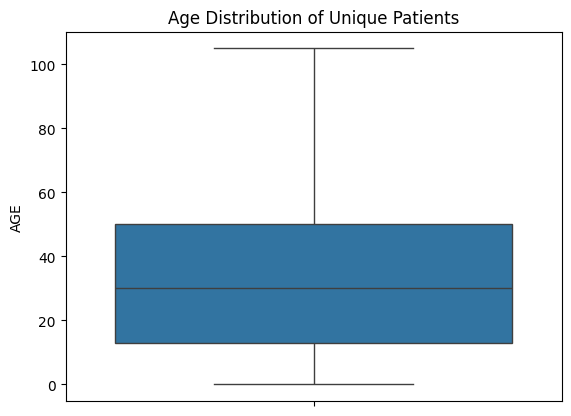

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(unique_patient_df['AGE'])
plt.title('Age Distribution of Unique Patients')
plt.show()

In [ ]:
df['AGE'].max()

110

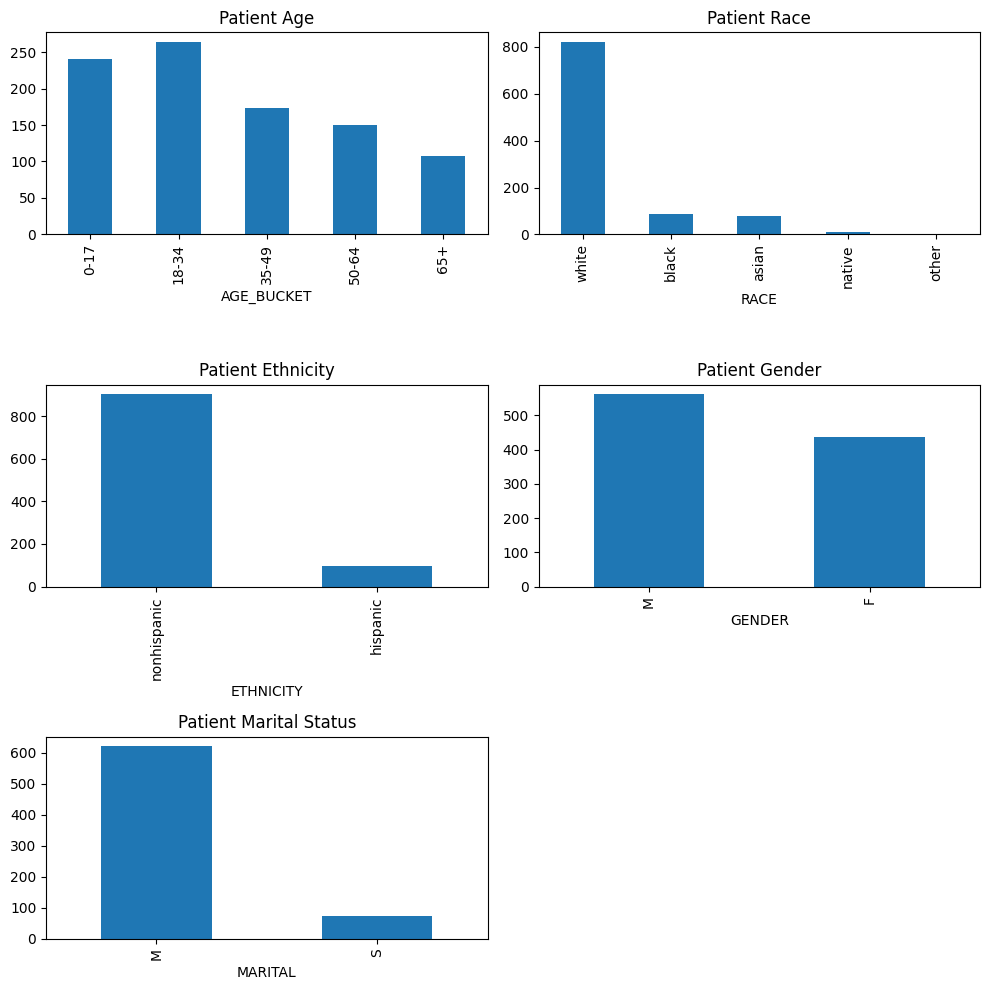

In [ ]:
unique_patients_df = df.drop_duplicates(subset=['PATIENT_ID'])[['PATIENT_ID', 'AGE', 'RACE', 'ETHNICITY', 'GENDER', 'MARITAL']].copy()

# Count demographics by unique patients
race_counts = unique_patients_df['RACE'].value_counts()
ethnicity_counts = unique_patients_df['ETHNICITY'].value_counts()
gender_counts = unique_patients_df['GENDER'].value_counts()
marital_counts = unique_patients_df['MARITAL'].value_counts()

# Group age by buckets - Re-apply age bucketing to the new unique_patients_df
age_bins = [0, 17, 34, 49, 64, df['AGE'].max()]
age_labels = ['0-17', '18-34', '35-49', '50-64', '65+']
unique_patients_df['AGE_BUCKET'] = pd.cut(unique_patients_df['AGE'], bins=age_bins, labels=age_labels, right=True)
age_bucket_counts = unique_patients_df['AGE_BUCKET'].value_counts().sort_index()

# Plot count of demographics
fig, axes = plt.subplots(3,2, figsize=(10, 10))

age_bucket_counts.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Patient Age')

race_counts.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Patient Race')

ethnicity_counts.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Patient Ethnicity')

gender_counts.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Patient Gender')

marital_counts.plot(kind='bar', ax=axes[2,0])
axes[2,0].set_title('Patient Marital Status')

# Hide the unused subplot
axes[2,1].axis('off')

plt.tight_layout()
plt.show()

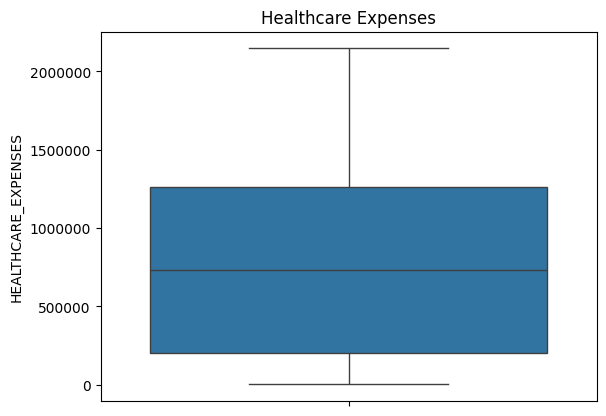

In [ ]:
unique_patient_expenses = df.drop_duplicates(subset=['PATIENT_ID'])[['PATIENT_ID', 'HEALTHCARE_EXPENSES', 'AGE', 'GENDER', 'RACE']].copy()

sns.boxplot(unique_patient_expenses['HEALTHCARE_EXPENSES'])
plt.title('Healthcare Expenses')
# To display numbers as plain text (no scientific notation)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

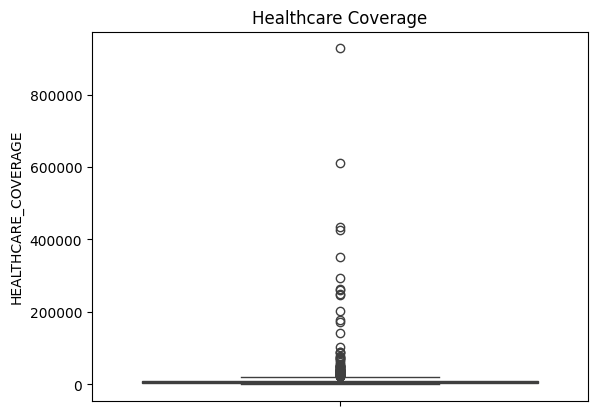

In [ ]:
unique_patient_coverage = df.drop_duplicates(subset=['PATIENT_ID'])[['PATIENT_ID', 'HEALTHCARE_COVERAGE']].copy()

sns.boxplot(unique_patient_coverage['HEALTHCARE_COVERAGE'])
plt.title('Healthcare Coverage')
plt.show()

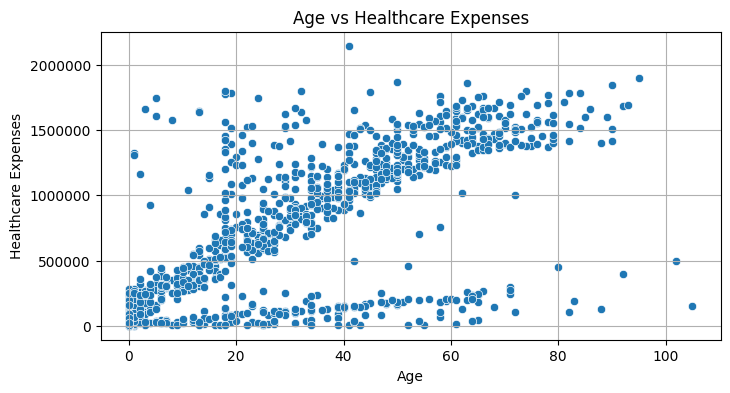

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=unique_patient_expenses, x='AGE', y='HEALTHCARE_EXPENSES')
plt.title('Age vs Healthcare Expenses')
plt.xlabel('Age')
plt.ylabel('Healthcare Expenses')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()

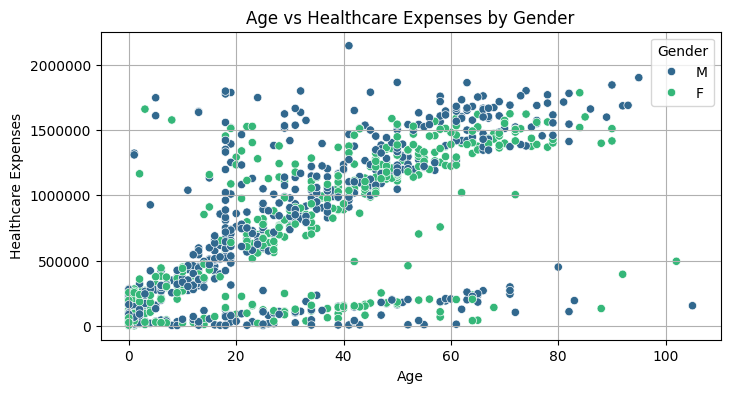

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=unique_patient_expenses, x='AGE', y='HEALTHCARE_EXPENSES', hue='GENDER', palette='viridis')
plt.title('Age vs Healthcare Expenses by Gender')
plt.xlabel('Age')
plt.ylabel('Healthcare Expenses')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.legend(title='Gender')
plt.show()

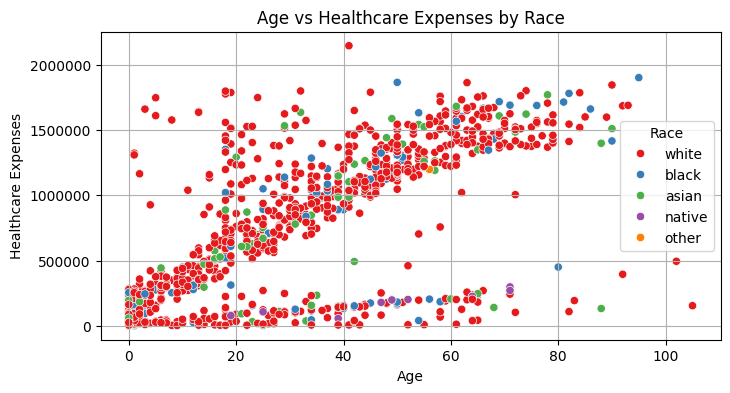

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=unique_patient_expenses, x='AGE', y='HEALTHCARE_EXPENSES', hue='RACE', palette='Set1')
plt.title('Age vs Healthcare Expenses by Race')
plt.xlabel('Age')
plt.ylabel('Healthcare Expenses')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.legend(title='Race')
plt.show()

In [ ]:
#Create pivot for number of encounters by description
df_pivot = df.pivot_table(index='DESCRIPTION', values='Id', aggfunc='count').sort_values(by='DESCRIPTION', ascending=True)
print(df_pivot)

                                                       Id
DESCRIPTION                                              
Admission to surgical department                       30
Admission to thoracic surgery department                3
Allergic disorder follow-up assessment                 13
Allergic disorder initial assessment                   26
Asthma follow-up                                      225
Cardiac Arrest                                         41
Consultation for treatment                            818
Death Certification                                    16
Discussion about treatment (procedure)                  9
Domiciliary or rest home patient evaluation and...     79
Drug rehabilitation and detoxification                122
Emergency Encounter                                   348
Emergency Room Admission                              277
Emergency hospital admission for asthma                42
Emergency room admission (procedure)                  747
Encounter Inpa

In [ ]:
# Make sure to handle NaN values appropriately if they exist and you don't want them converted to strings.
# In this example, .astype(str) is used to ensure .str.upper() works even if there are non-string types.
# Then, non-string NaN values are converted back to actual NaN using .replace('NAN', np.nan)
import numpy as np

df['DESCRIPTION'] = df['DESCRIPTION'].astype(str).str.upper().replace('NAN', np.nan)

# Display the unique values to confirm normalization
print(df['DESCRIPTION'].unique())

['GENERAL EXAMINATION OF PATIENT (PROCEDURE)'
 'WELL CHILD VISIT (PROCEDURE)' 'ENCOUNTER FOR CHECK UP (PROCEDURE)'
 'STROKE' 'ENCOUNTER FOR SYMPTOM' "ENCOUNTER FOR 'CHECK-UP'"
 'EMERGENCY ROOM ADMISSION (PROCEDURE)'
 'OBSTETRIC EMERGENCY HOSPITAL ADMISSION' 'EMERGENCY ENCOUNTER'
 'ENCOUNTER INPATIENT' 'INPATIENT STAY (FINDING)' 'ENCOUNTER FOR PROBLEM'
 'NON-URGENT ORTHOPEDIC ADMISSION' 'FOLLOW-UP ENCOUNTER' 'CARDIAC ARREST'
 'POSTTRAUMATIC STRESS DISORDER' 'OUTPATIENT PROCEDURE'
 'TELEPHONE ENCOUNTER (PROCEDURE)' 'ENCOUNTER FOR PROBLEM (PROCEDURE)'
 'URGENT CARE CLINIC (PROCEDURE)' 'PATIENT ENCOUNTER PROCEDURE'
 'CONSULTATION FOR TREATMENT' 'PRENATAL INITIAL VISIT'
 'ADMISSION TO SURGICAL DEPARTMENT' 'PRENATAL VISIT'
 'EMERGENCY ROOM ADMISSION' 'EMERGENCY HOSPITAL ADMISSION FOR ASTHMA'
 'HYPERTENSION FOLLOW-UP ENCOUNTER'
 'POSTOPERATIVE FOLLOW-UP VISIT (PROCEDURE)'
 'DISCUSSION ABOUT TREATMENT (PROCEDURE)' 'POSTNATAL VISIT'
 'PATIENT-INITIATED ENCOUNTER' 'ASTHMA FOLLOW-UP' 'MYOCARDIAL 

In [ ]:
#Remove all single quotes from the DESCRIPTION column
df['DESCRIPTION'] = df['DESCRIPTION'].str.replace("'", "", regex=False)

#Replace 'ENCOUNTER FOR CHECK-UP' (after single quote removal) with 'ENCOUNTER FOR CHECK UP'
df['DESCRIPTION'] = df['DESCRIPTION'].str.replace("ENCOUNTER FOR CHECK-UP", "ENCOUNTER FOR CHECK UP", regex=False)


In [ ]:
#Replace "ENCOUNTER FOR PROBLEM" with "ENCOUNTER FOR SYMPTOM" since in healthcare, those are likely synonymous
df['DESCRIPTION'] = df['DESCRIPTION'].str.replace("ENCOUNTER FOR PROBLEM", "ENCOUNTER FOR SYMPTOM", regex=False)
df['DESCRIPTION'] = df['DESCRIPTION'].str.replace("ENCOUNTER FOR PROBLEM (PROCEDURE)", "ENCOUNTER FOR SYMPTOM (PROCEDURE)", regex=False)

#Replace "TELEPHONE ENCOUNTER (PROCEDURE)" with "TELEMEDICINE CONSULTATION WITH PATIENT" since procedures are usually performed through physical contact
df['DESCRIPTION'] = df['DESCRIPTION'].str.replace("TELEPHONE ENCOUNTER (PROCEDURE)", "TELEMEDICINE CONSULTATION WITH PATIENT", regex=False)

# Recreate the pivot table after modifications
df_pivot = df.pivot_table(index='DESCRIPTION', values='Id', aggfunc='count').sort_values(by='DESCRIPTION', ascending=True)
print(df_pivot)

                                                       Id
DESCRIPTION                                              
ADMISSION TO SURGICAL DEPARTMENT                       30
ADMISSION TO THORACIC SURGERY DEPARTMENT                3
ALLERGIC DISORDER FOLLOW-UP ASSESSMENT                 13
ALLERGIC DISORDER INITIAL ASSESSMENT                   26
ASTHMA FOLLOW-UP                                      225
CARDIAC ARREST                                         41
CONSULTATION FOR TREATMENT                            818
DEATH CERTIFICATION                                    16
DISCUSSION ABOUT TREATMENT (PROCEDURE)                  9
DOMICILIARY OR REST HOME PATIENT EVALUATION AND...     79
DRUG REHABILITATION AND DETOXIFICATION                122
EMERGENCY ENCOUNTER                                   348
EMERGENCY HOSPITAL ADMISSION FOR ASTHMA                42
EMERGENCY ROOM ADMISSION                              277
EMERGENCY ROOM ADMISSION (PROCEDURE)                  747
ENCOUNTER FOR 

In [ ]:
#Check for records with a STOP Date/Time < START Date/Time
df[df['STOP'] < df['START']]

,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE


In [ ]:
#Calculate encounter duration
df['DURATION'] = df['STOP'] - df['START']
df.head()

,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,DURATION
0,7da3a8f6-ae2f-47a1-9cbd-09e792bb5c3f,2012-05-30 18:15:56+00:00,2012-05-30 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,54,0 days 00:15:00
1,c031a292-af66-4724-a3bd-13feba60a265,2014-06-11 18:15:56+00:00,2014-06-11 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,56,0 days 00:15:00
2,c9b65029-984d-4c8e-b6e5-f24b4c3320fb,2010-05-19 18:15:56+00:00,2010-05-19 18:45:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,52,0 days 00:30:00
3,d8212a9d-fb80-4a39-bbb5-850738aa993d,2011-05-25 18:15:56+00:00,2011-05-25 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,53,0 days 00:15:00
4,aa00fafc-442c-4061-a5e5-a1d38da642d6,2015-06-17 18:15:56+00:00,2015-06-17 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Boston,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,57,0 days 00:15:00


In [ ]:
#Convert duration from days, hours, min, sec to hours
df['DURATION_HOURS'] = df['DURATION'].dt.total_seconds() / 3600
df.head()

,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,DURATION,DURATION_HOURS
0,7da3a8f6-ae2f-47a1-9cbd-09e792bb5c3f,2012-05-30 18:15:56+00:00,2012-05-30 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,54,0 days 00:15:00,0.25
1,c031a292-af66-4724-a3bd-13feba60a265,2014-06-11 18:15:56+00:00,2014-06-11 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,56,0 days 00:15:00,0.25
2,c9b65029-984d-4c8e-b6e5-f24b4c3320fb,2010-05-19 18:15:56+00:00,2010-05-19 18:45:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,52,0 days 00:30:00,0.50
3,d8212a9d-fb80-4a39-bbb5-850738aa993d,2011-05-25 18:15:56+00:00,2011-05-25 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,53,0 days 00:15:00,0.25
4,aa00fafc-442c-4061-a5e5-a1d38da642d6,2015-06-17 18:15:56+00:00,2015-06-17 18:30:56+00:00,bfb101aa-8d36-422b-8e5c-b7275d279de0,00717240-296a-35b2-a336-8e3d9f085fce,35b68d18-e67e-37f7-aa49-fcc046f1a289,d47b3510-2895-3b70-9897-342d681c769d,wellness,162673000,GENERAL EXAMINATION OF PATIENT (PROCEDURE),...,Massachusetts,Suffolk County,2128,42.318568,-71.124926,1272094.625,5267.759766,57,0 days 00:15:00,0.25


In [ ]:
#Calculate average duration by encounter type
df_duration_hours_pivot = df.pivot_table(index='DESCRIPTION', values='DURATION_HOURS', aggfunc='mean').sort_values(by='DESCRIPTION', ascending=True)
print(df_duration_hours_pivot)

                                                    DURATION_HOURS
DESCRIPTION                                                       
ADMISSION TO SURGICAL DEPARTMENT                         25.533333
ADMISSION TO THORACIC SURGERY DEPARTMENT                 29.666667
ALLERGIC DISORDER FOLLOW-UP ASSESSMENT                    0.774359
ALLERGIC DISORDER INITIAL ASSESSMENT                      0.637821
ASTHMA FOLLOW-UP                                          0.250000
CARDIAC ARREST                                            1.750000
CONSULTATION FOR TREATMENT                                0.307559
DEATH CERTIFICATION                                       0.250000
DISCUSSION ABOUT TREATMENT (PROCEDURE)                    0.250000
DOMICILIARY OR REST HOME PATIENT EVALUATION AND...        0.500000
DRUG REHABILITATION AND DETOXIFICATION                   24.000000
EMERGENCY ENCOUNTER                                       1.086207
EMERGENCY HOSPITAL ADMISSION FOR ASTHMA                   1.00

In [ ]:
checkup_procedures = df[df['DESCRIPTION'] == 'ENCOUNTER FOR CHECK UP (PROCEDURE)']
display(checkup_procedures['DURATION_HOURS'].describe())

,DURATION_HOURS
count,4017.000000
mean,5724.493279
std,46063.147395
min,0.250000
25%,0.250000
50%,0.250000
75%,0.250000
max,766080.250000


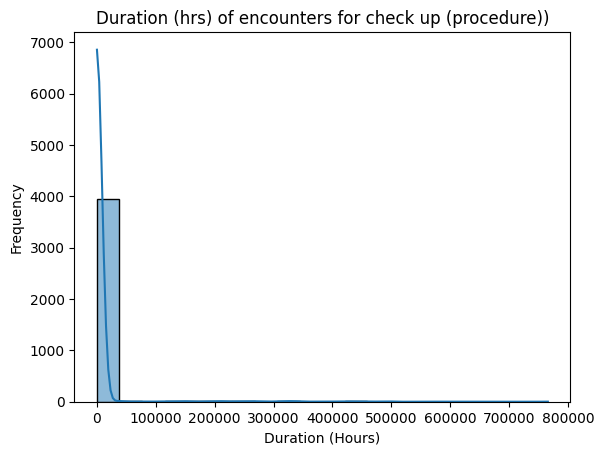

In [ ]:
sns.histplot(checkup_procedures['DURATION_HOURS'], bins=20, kde=True)
plt.title('Duration (hrs) of encounters for check up (procedure))')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print('Displaying records with DURATION_HOURS > 1 day (24 hours):')
display(checkup_procedures[checkup_procedures['DURATION_HOURS'] > 24].sort_values(by='DURATION_HOURS', ascending=False))

Displaying records with DURATION_HOURS > 1 day (24 hours):


,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,DURATION,DURATION_HOURS
11896,f76ab201-ca37-4525-acd7-1b8c880de7d2,1924-04-26 18:44:55+00:00,2011-09-17 18:59:55+00:00,8b570796-e100-47cd-a634-dbc8cd35857e,4bdaa4c2-c664-3089-aee2-7137abbad27f,c381c694-d45a-3cc1-a818-5b70c4511f7e,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Worcester County,1535,42.307458,-72.083617,1.599140e+06,28560.980469,6,31920 days 00:15:00,766080.25
11897,80a42f31-e46f-48c5-b57e-9d7aac457f2a,1931-06-27 18:44:55+00:00,2011-07-23 18:44:55+00:00,8b570796-e100-47cd-a634-dbc8cd35857e,4bdaa4c2-c664-3089-aee2-7137abbad27f,c381c694-d45a-3cc1-a818-5b70c4511f7e,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Worcester County,1535,42.307458,-72.083617,1.599140e+06,28560.980469,13,29246 days 00:00:00,701904.00
42793,c3a46b82-b083-4e1b-9a40-9351f1c2abdf,1942-01-12 02:34:12+00:00,2018-09-17 02:34:12+00:00,c9942738-49f3-4459-818f-8da20072ff76,f4e7709c-02f6-37ca-aeea-8247d74e88e7,4d0bb3a1-8259-3749-a330-e9c17879d81a,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Middlesex County,2474,42.406609,-71.199838,1.412705e+06,15725.500000,6,28007 days 00:00:00,672168.00
44024,e7b97c7d-7074-4403-ad94-78c0ab6f2a1e,1945-09-12 00:54:28+00:00,2015-04-22 00:54:28+00:00,d07f23f8-3bd1-4db1-9a36-51aedbe60821,fbf6180e-b800-3ebe-b91d-93d0288c400e,a83b5619-bcec-3877-9a3e-cbd20c29e158,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Franklin County,1301,42.573737,-72.644340,2.590469e+05,19402.560547,0,25424 days 00:00:00,610176.00
7853,f331a748-fbee-4dd9-bd9f-39776e668082,1948-08-19 12:15:51+00:00,2016-01-07 12:30:51+00:00,c1cfae08-b141-40ea-a8bb-78c46cde0f3c,3d10019f-c88e-3de5-9916-6107b9c0263d,4b04cd2f-3f27-35bc-8069-f4ca6339529f,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Middlesex County,2451,42.355170,-71.227170,2.529076e+05,30219.480469,2,24612 days 00:15:00,590688.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36017,eae49e8f-4e3b-4bb6-ad07-5a15cce0c4ec,2016-11-29 22:09:11+00:00,2017-01-31 22:09:11+00:00,f079528f-e325-4c13-ac9f-da60cb48cdb3,d692e283-0833-3201-8e55-4f868a9c0736,f4eb93d1-9187-3cfb-83a4-6d9cd77f7df6,6e2f1a2d-27bd-3701-8d08-dae202c58632,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Middlesex County,None,42.463366,-71.090051,1.003575e+06,15801.440430,42,63 days 00:00:00,1512.00
8470,c01c18c8-9bd3-4601-a71c-ccddc3c4c6d7,2013-07-16 21:00:08+00:00,2013-09-10 21:00:08+00:00,70794fdc-0702-4e0f-9682-8ec5d7145436,3d10019f-c88e-3de5-9916-6107b9c0263d,4b04cd2f-3f27-35bc-8069-f4ca6339529f,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Middlesex County,2458,42.345295,-71.176367,1.465280e+06,24916.349609,73,56 days 00:00:00,1344.00
7901,24f6327a-e54b-462f-ac9c-f1d7ae9a148e,2018-11-08 12:15:51+00:00,2018-12-27 12:15:51+00:00,c1cfae08-b141-40ea-a8bb-78c46cde0f3c,3d10019f-c88e-3de5-9916-6107b9c0263d,4b04cd2f-3f27-35bc-8069-f4ca6339529f,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Middlesex County,2451,42.355170,-71.227170,2.529076e+05,30219.480469,72,49 days 00:00:00,1176.00
3703,193d1296-e2d5-4e0b-8de7-1f6d6373a71c,2011-10-07 02:57:15+00:00,2011-10-14 02:57:15+00:00,b4f1aa40-1a13-43cc-9528-8dcde700ecf0,23834663-ed53-3da9-b330-d6e1ecb8428e,af42f305-3f0c-396d-8303-9cbdb900a516,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,185349003,ENCOUNTER FOR CHECK UP (PROCEDURE),...,Massachusetts,Bristol County,None,41.740481,-70.977367,1.512467e+06,9244.000000,61,7 days 00:00:00

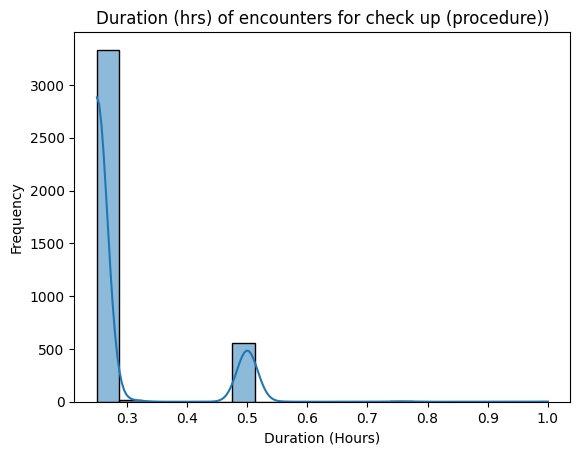

In [ ]:
#Filter out records with an encounter type of ENCOUNTER FOR CHECK UP (PROCEDURE) and DURATION_HOURS > 24 hours
df = df[~((df['DESCRIPTION'] == 'ENCOUNTER FOR CHECK UP (PROCEDURE)') & (df['DURATION_HOURS'] > 24))]

#Recreate histogram for DURATION_HOURS of ENCOUNTER FOR CHECK UP (PROCEDURE)
checkup_procedures = df[df['DESCRIPTION'] == 'ENCOUNTER FOR CHECK UP (PROCEDURE)']
sns.histplot(checkup_procedures['DURATION_HOURS'], bins=20, kde=True)
plt.title('Duration (hrs) of encounters for check up (procedure))')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
eval = df[df['DESCRIPTION'] == 'PERIODIC REEVALUATION AND MANAGEMENT OF HEALTHY INDIVIDUAL (PROCEDURE)']
display(eval['DURATION_HOURS'].describe())

,DURATION_HOURS
count,8.000000
mean,669.595833
std,1826.020767
min,24.000000
25%,24.000000
50%,24.000000
75%,24.000000
max,5188.766667


In [ ]:
print('Display records with DURATION_HOURS > 1 day (24 hours):')
display(eval[eval['DURATION_HOURS'] > 24].sort_values(by='DURATION_HOURS', ascending=False))

Display records with DURATION_HOURS > 1 day (24 hours):


,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,DURATION,DURATION_HOURS
41767,e492dfc6-7e0b-42bf-bcd8-a75ce50d340a,1984-03-25 19:13:29+00:00,1984-10-27 23:59:29+00:00,cdef53d5-0537-4073-8874-79fa5e0346e6,ef6ab57c-ed94-3dbe-9861-812d515918b3,77a7881d-6dd5-32e1-9e18-521a59749572,4d71f845-a6a9-3c39-b242-14d25ef86a8d,inpatient,86013001,PERIODIC REEVALUATION AND MANAGEMENT OF HEALTH...,...,Massachusetts,Plymouth County,None,41.856827,-70.870052,1075827.75,11495.179688,43,216 days 04:46:00,5188.766667


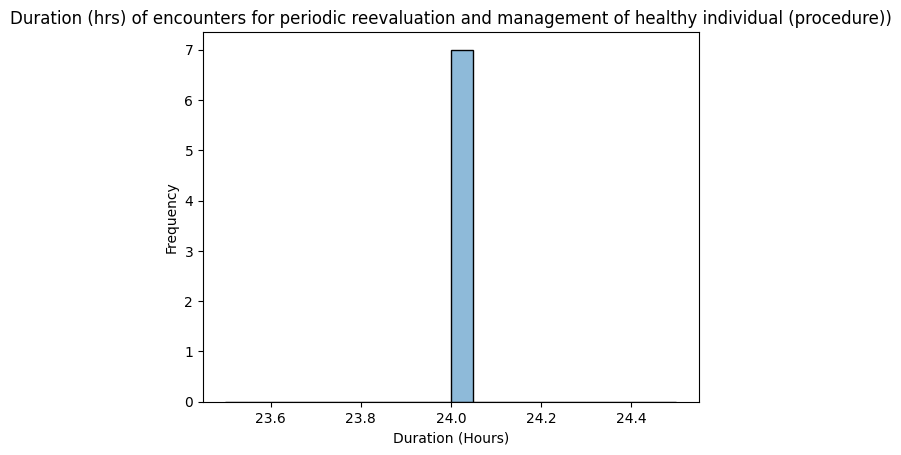

In [ ]:
#Filter out records with an encounter type of PERIODIC REEVALUATION AND MANAGEMENT OF HEALTHY INDIVIDUAL (PROCEDURE) and DURATION_HOURS > 24 hours
df = df[~((df['DESCRIPTION'] == 'PERIODIC REEVALUATION AND MANAGEMENT OF HEALTHY INDIVIDUAL (PROCEDURE)') & (df['DURATION_HOURS'] > 24))]

#Recreate histogram for DURATION_HOURS of PERIODIC REEVALUATION AND MANAGEMENT OF HEALTHY INDIVIDUAL (PROCEDURE)
eval = df[df['DESCRIPTION'] == 'PERIODIC REEVALUATION AND MANAGEMENT OF HEALTHY INDIVIDUAL (PROCEDURE)']
sns.histplot(eval['DURATION_HOURS'], bins=20, kde=True)
plt.title('Duration (hrs) of encounters for periodic reevaluation and management of healthy individual (procedure))')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
symptom_procedures = df[df['DESCRIPTION'] == 'ENCOUNTER FOR SYMPTOM (PROCEDURE)']
display(symptom_procedures['DURATION_HOURS'].describe())

,DURATION_HOURS
count,5084.000000
mean,97.775180
std,6804.359037
min,0.250000
25%,0.250000
50%,2.250000
75%,3.250000
max,485164.666667


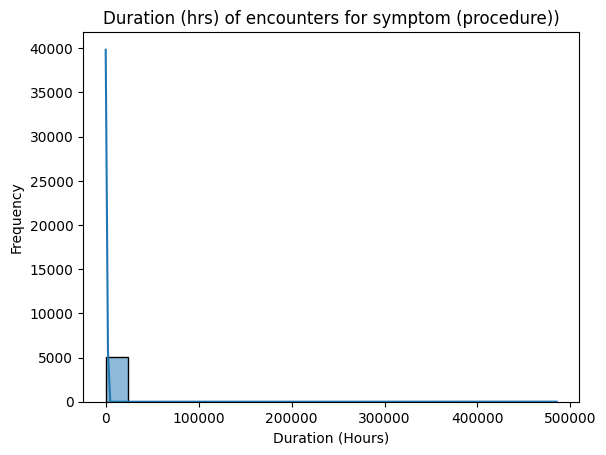

In [ ]:
sns.histplot(symptom_procedures['DURATION_HOURS'], bins=20, kde=True)
plt.title('Duration (hrs) of encounters for symptom (procedure))')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

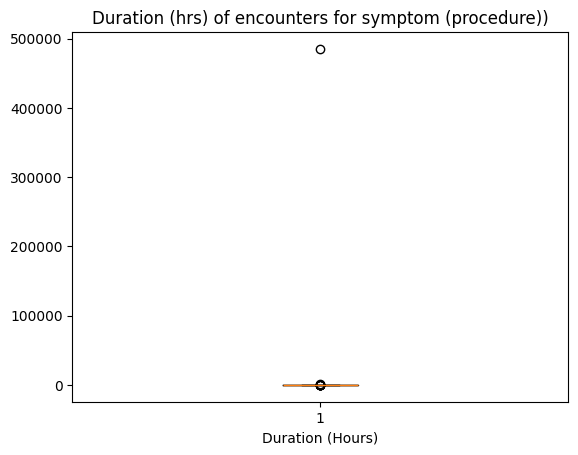

In [ ]:
plt.boxplot(symptom_procedures['DURATION_HOURS'])
plt.title('Duration (hrs) of encounters for symptom (procedure))')
plt.xlabel('Duration (Hours)')
plt.show()

In [ ]:
print('Displaying records with DURATION_HOURS > 1 day (24 hours):')
display(symptom_procedures[symptom_procedures['DURATION_HOURS'] > 24].sort_values(by='DURATION_HOURS', ascending=False))

Displaying records with DURATION_HOURS > 1 day (24 hours):


,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,DURATION,DURATION_HOURS
43236,ca53f679-58a4-4c23-8aa6-139415a267ac,1962-09-16 13:55:22+00:00,2018-01-20 18:35:22+00:00,a6028f3c-c013-44af-97ff-949dd2096ed3,f71ce1a9-cca7-3295-9a1e-c88ac3479b6f,1045937e-4c7c-3dee-81de-c8ed516c31ae,d47b3510-2895-3b70-9897-342d681c769d,inpatient,185345009,ENCOUNTER FOR SYMPTOM (PROCEDURE),...,Massachusetts,Middlesex County,None,42.392563,-71.491429,1.005410e+06,21606.210938,15,20215 days 04:40:00,485164.666667
22063,08bbfc88-2f00-4f2f-aac4-c33d99153446,2018-04-12 19:11:49+00:00,2018-06-25 23:19:49+00:00,bae73dce-20fa-4a6a-8e46-b2ed541f9296,8881e3ee-e915-31b3-867f-8e2fbe41e887,b6c72690-131c-355f-91d0-7fc93ccc80e1,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,inpatient,185345009,ENCOUNTER FOR SYMPTOM (PROCEDURE),...,Massachusetts,Suffolk County,None,42.467686,-70.961675,3.085401e+04,0.000000,59,74 days 04:08:00,1780.133333
31002,8e81c925-5932-446d-96e6-e3976cdc3f80,2015-09-19 23:51:30+00:00,2015-09-21 00:27:30+00:00,a0af88b5-1568-4545-a71a-3073c2c2ac72,c44f361c-2efb-3050-8f97-0354a12e2920,32549af3-da1c-3fd3-ab66-625738f56d21,047f6ec3-6215-35eb-9608-f9dda363a44c,inpatient,185347001,ENCOUNTER FOR SYMPTOM (PROCEDURE),...,Massachusetts,Norfolk County,2189,42.149408,-70.917741,1.235608e+06,6584.399902,44,1 days 00:36:00,24.600000
41698,b90640cc-2674-4adb-9dbb-16edb67f1161,2017-06-12 02:21:14+00:00,2017-06-13 02:56:14+00:00,a7b167c9-6230-4a8f-b808-9ada2dd35973,ef6ab57c-ed94-3dbe-9861-812d515918b3,77a7881d-6dd5-32e1-9e18-521a59749572,6e2f1a2d-27bd-3701-8d08-dae202c58632,inpatient,185347001,ENCOUNTER FOR SYMPTOM (PROCEDURE),...,Massachusetts,Plymouth County,None,41.837334,-70.872999,7.639332e+05,9161.519531,33,1 days 00:35:00,24.583333
19808,692d125d-5aab-4c2f-9fb6-f4a1e71d71cf,2018-05-17 12:31:28+00:00,2018-05-18 13:03:28+00:00,e93ddf88-f6bf-47d5-a82c-025ba00a6790,7b50426f-b50b-3d7c-ab22-04a0e1632ac8,e54433bd-8112-36aa-ab01-e8ca07614aa4,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,inpatient,185347001,ENCOUNTER FOR SYMPTOM (PROCEDURE),...,Massachusetts,Suffolk County,2126,42.327371,-71.036989,8.336210e+03,0.000000,48,1 days 00:32:00,24.533333


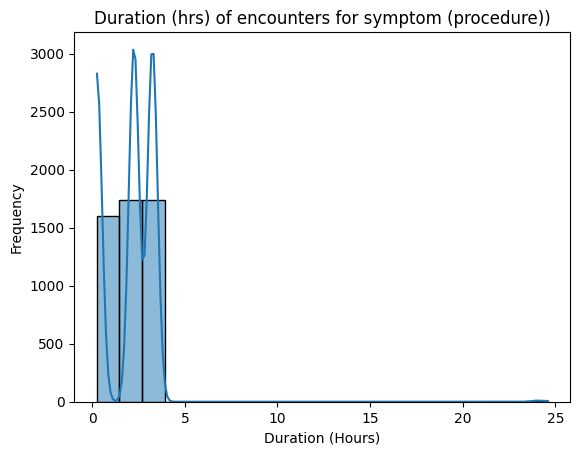

In [ ]:
#Filter out records with an encounter type of ENCOUNTER FOR SYMPTOM (PROCEDURE) and DURATION_HOURS > 25 hours
df = df[~((df['DESCRIPTION'] == 'ENCOUNTER FOR SYMPTOM (PROCEDURE)') & (df['DURATION_HOURS'] > 25))]

#Recreate histogram for DURATION_HOURS of ENCOUNTER FOR SYMPTOM (PROCEDURE)
symptom_procedures = df[df['DESCRIPTION'] == 'ENCOUNTER FOR SYMPTOM (PROCEDURE)']
sns.histplot(symptom_procedures['DURATION_HOURS'], bins=20, kde=True)
plt.title('Duration (hrs) of encounters for symptom (procedure))')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
ER = df[df['DESCRIPTION'] == 'EMERGENCY ROOM ADMISSION']
display(ER['DURATION_HOURS'].describe())

,DURATION_HOURS
count,277.000000
mean,196.183394
std,3241.576560
min,1.000000
25%,1.000000
50%,1.000000
75%,1.166667
max,53952.000000


In [ ]:
print('Displaying records with DURATION_HOURS > 1 day (24 hours):')
display(ER[ER['DURATION_HOURS'] > 24].sort_values(by='DURATION_HOURS', ascending=False))

Displaying records with DURATION_HOURS > 1 day (24 hours):


,Id,START,STOP,PATIENT_ID,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,DURATION,DURATION_HOURS
35637,2da42afd-7f90-4916-8abf-304280addd15,2007-06-09 08:42:58+00:00,2013-08-04 08:42:58+00:00,2ebc60de-f35e-40ef-ab09-ed736e6b4caa,d692e283-0833-3201-8e55-4f868a9c0736,f4eb93d1-9187-3cfb-83a4-6d9cd77f7df6,d47b3510-2895-3b70-9897-342d681c769d,emergency,50849002,EMERGENCY ROOM ADMISSION,...,Massachusetts,Essex County,1906,42.507132,-71.020611,514456.1875,3430.52002,11,2248 days,53952.0


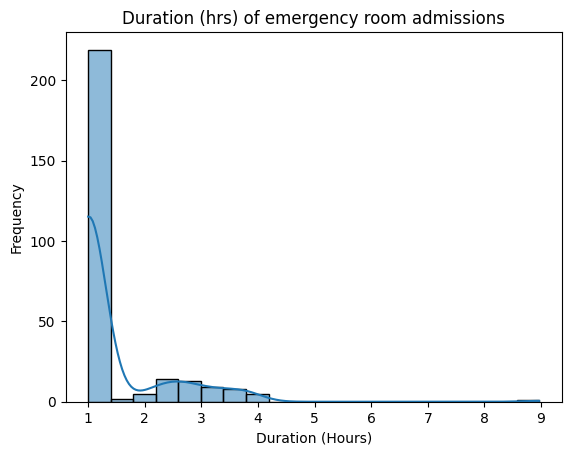

In [ ]:
#Filter out records with an encounter type of EMERGENCY ROOM ADMISSION and DURATION_HOURS > 24 hours
df = df[~((df['DESCRIPTION'] == 'EMERGENCY ROOM ADMISSION') & (df['DURATION_HOURS'] > 24))]

#Recreate histogram for DURATION_HOURS of EMERGENCY ROOM ADMISSION
ER = df[df['DESCRIPTION'] == 'EMERGENCY ROOM ADMISSION']
sns.histplot(ER['DURATION_HOURS'], bins=20, kde=True)
plt.title('Duration (hrs) of emergency room admissions')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
display(df['DURATION'].describe())

,DURATION
count,44689
mean,0 days 03:24:05.924947973
std,1 days 12:45:30.809998693
min,0 days 00:15:00
25%,0 days 00:15:00
50%,0 days 00:15:00
75%,0 days 00:45:00
max,47 days 00:00:00


In [ ]:
#Recalculate average duration by encounter type
df_duration_hours_pivot = df.pivot_table(index='DESCRIPTION', values='DURATION_HOURS', aggfunc='mean').sort_values(by='DESCRIPTION', ascending=True)
print(df_duration_hours_pivot)

                                                    DURATION_HOURS
DESCRIPTION                                                       
ADMISSION TO SURGICAL DEPARTMENT                         25.533333
ADMISSION TO THORACIC SURGERY DEPARTMENT                 29.666667
ALLERGIC DISORDER FOLLOW-UP ASSESSMENT                    0.774359
ALLERGIC DISORDER INITIAL ASSESSMENT                      0.637821
ASTHMA FOLLOW-UP                                          0.250000
CARDIAC ARREST                                            1.750000
CONSULTATION FOR TREATMENT                                0.307559
DEATH CERTIFICATION                                       0.250000
DISCUSSION ABOUT TREATMENT (PROCEDURE)                    0.250000
DOMICILIARY OR REST HOME PATIENT EVALUATION AND...        0.500000
DRUG REHABILITATION AND DETOXIFICATION                   24.000000
EMERGENCY ENCOUNTER                                       1.086207
EMERGENCY HOSPITAL ADMISSION FOR ASTHMA                   1.00

In [ ]:
from pandas_gbq import to_gbq

project_id = "project-6a80f461-7192-4ba7-a5f"

to_gbq(
    df,
    destination_table="synthea_patients.clean_patient_encounters",
    project_id=project_id,
    if_exists="replace"
)

/usr/local/lib/python3.12/dist-packages/pandas_gbq/schema/pandas_to_bigquery.py:159: UserWarning: Could not determine the type of columns: DURATION
  warnings.warn(msg)
100%|██████████| 1/1 [00:00<00:00, 14563.56it/s]
